# Full End-to-End Pretraining (ChemBL + Zinc + Tox21)
Training supports automatic crash recovery by resuming from the latest checkpoint when `AUTO_RESUME=True`.


This notebook aims to use the pretraining setup from `full_PreTrained_VAE.ipynb` as a starting point architecture for end-to-end model training of the VAE model with a prediction head for Tox21 labels. 

Key dataset change:
- include `tox21_train` in the pretraining train split
- include `tox21_val` in the pretraining validation split
- enforce no canonical-smiles overlap across train/val/test (tox21 split assignment takes priority)
- Property prediction loss incorporated into loss function
- Training end-to-end with prediction head

### Imports and config

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120

# ==== DATA SPLIT =====
VAL_FRAC = 0.10
TEST_FRAC = 0.10

# ==== TRAINING CONTROL =====
MIN_EPOCHS = 50
MAX_EPOCHS = 120
EARLY_STOPPING_PATIENCE = 12

# ==== LR SCHEDULER =====
LR_SCHEDULER_FACTOR = 0.25
LR_SCHEDULER_PATIENCE = 4

# ===== CORE MODEL =====
LATENT_DIM = 292
EMBED_DIM = 256
HIDDEN_DIM = 512
NUM_TASKS = 12
DROPOUT = 0.1

# ===== TRAINING =====
BATCH_SIZE = 128
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.0 

# ==========================================
# PHASE CONFIGURATION
# ==========================================
PHASE1_EPOCHS = 90
PHASE1_LR = 5e-4  
PHASE1_RECON_WEIGHT = 1.0

PHASE2_EPOCHS = 80 
PHASE2_LR = 5e-5
PHASE2_PRED_WEIGHT = 2.0
PHASE2_RECON_WEIGHT = 3.0 

# =============================================================================

AUTO_RESUME = False

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "full-pretrain-chembl-zinc-tox21-seqconv"

# ===== CHECKPOINT SETTINGS =====
# Changed directory name as requested
CHECKPOINT_DIR = Path("artifacts") / "end-to-end_checkpoint"
CHECKPOINT_STEM = "e2evae_full_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = False  # Set to False to only keep Last/Best per phase
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL, Zinc, and Tox21 datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

TOX21_TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

def load_tox21_labels(path):
    df = pd.read_csv(path)

    y = df[TOX21_TASKS].values.astype(np.float32)
    mask = ~np.isnan(y)

    y = np.nan_to_num(y, nan=0.0)

    return y, mask.astype(np.float32)

y_train_tox21, mask_train_tox21 = load_tox21_labels(TOX21_TRAIN_PATH)
y_val_tox21, mask_val_tox21 = load_tox21_labels(TOX21_VAL_PATH)
y_test_tox21, mask_test_tox21 = load_tox21_labels(TOX21_TEST_PATH) 

print(f"ChemBL unique SMILES:      {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:        {len(zinc_smiles):,}")
print(f"Base pretraining unique:   {len(pretrain_smiles):,}")
print(f"Tox21 train unique SMILES: {len(tox21_train_smiles):,}")
print(f"Tox21 val unique SMILES:   {len(tox21_val_smiles):,}")
print(f"Tox21 test unique SMILES:  {len(tox21_test_smiles):,}") 

ChemBL unique SMILES:      23,871
Zinc unique SMILES:        249,455
Base pretraining unique:   273,321
Tox21 train unique SMILES: 6,258
Tox21 val unique SMILES:   782
Tox21 test unique SMILES:  783


### Create base split, merge Tox21 train/val, enforce split isolation, and convert to SELFIES

In [3]:
def split_list(data, val_frac=0.1, test_frac=0.1, seed=42):
    """
    Standard utility to split a list into Train, Val, and Test.
    """
    random.seed(seed)
    data_copy = data.copy()
    random.shuffle(data_copy)
    
    n = len(data_copy)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    
    test_set = data_copy[:n_test]
    val_set = data_copy[n_test : n_test + n_val]
    train_set = data_copy[n_test + n_val :]
    
    return train_set, val_set, test_set

In [4]:
def process_aligned_data(smiles_list, labels=None, masks=None, max_len=MAX_LEN):
    """
    Unified processor that keeps SELFIES, Labels, and Masks perfectly synced.
    """
    clean_selfies = []
    clean_labels = []
    clean_masks = []
    
    dropped_enc = 0
    dropped_len = 0

    for i, smi in enumerate(smiles_list):
        # 1. Attempt SELFIES encoding
        try:
            sf_str = sf.encoder(smi)
        except Exception:
            dropped_enc += 1
            continue
        
        # 2. Check token length
        if len(list(sf.split_selfies(sf_str))) > max_len:
            dropped_len += 1
            continue
            
        # 3. If valid, keep the selfie and the corresponding label/mask row
        clean_selfies.append(sf_str)
        if labels is not None:
            clean_labels.append(labels[i])
            clean_masks.append(masks[i])

    print(f"Processed {len(smiles_list)} SMILES: Kept {len(clean_selfies)}, "
          f"Dropped {dropped_enc} (encoding), {dropped_len} (too long)")
    
    if labels is not None:
        return clean_selfies, np.array(clean_labels), np.array(clean_masks)
    return clean_selfies, None, None

# --- REPLACEMENT FOR YOUR SPLIT & CONVERSION LOGIC ---

# 1) Base ChemBL+Zinc split (keeping your logic)
base_train_smiles, base_val_smiles, base_test_smiles = split_list(pretrain_smiles, VAL_FRAC, TEST_FRAC, seed=SEED)

# 2) Tox21 Forbidden Set Cleaning
all_tox21_smiles = set(tox21_train_smiles) | set(tox21_val_smiles) | set(tox21_test_smiles)
pretrain_train_smiles = [s for s in base_train_smiles if s not in all_tox21_smiles]
pretrain_val_smiles = [s for s in base_val_smiles if s not in all_tox21_smiles]

# 3) Integrity check
assert set(pretrain_train_smiles).isdisjoint(all_tox21_smiles), "Overlap detected!"

# --- CONVERSION (The Fix) ---

print("\n>>> Converting Pre-training SMILES...")
# Pre-training doesn't have labels, so we pass None
pre_train_selfies, _, _ = process_aligned_data(pretrain_train_smiles)
pre_val_selfies, _, _ = process_aligned_data(pretrain_val_smiles)

print("\n>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...")
# We pass the labels and masks here so they are filtered alongside the SMILES
ft_train_selfies, y_train_aligned, mask_train_aligned = process_aligned_data(
    tox21_train_smiles, y_train_tox21, mask_train_tox21
)

ft_val_selfies, y_val_aligned, mask_val_aligned = process_aligned_data(
    tox21_val_smiles, y_val_tox21, mask_val_tox21
)

ft_test_selfies, y_test_aligned, mask_test_aligned = process_aligned_data(
    tox21_test_smiles, y_test_tox21, mask_test_tox21
)



>>> Converting Pre-training SMILES...
Processed 218326 SMILES: Kept 218003, Dropped 0 (encoding), 323 (too long)
Processed 27293 SMILES: Kept 27257, Dropped 0 (encoding), 36 (too long)

>>> Converting Fine-tuning (Tox21) SMILES with Aligned Labels...
Processed 6258 SMILES: Kept 6237, Dropped 0 (encoding), 21 (too long)
Processed 782 SMILES: Kept 770, Dropped 0 (encoding), 12 (too long)
Processed 783 SMILES: Kept 765, Dropped 0 (encoding), 18 (too long)


### Tokenization and encoding

In [5]:
# ==========================================
# VOCABULARY & ENCODING
# ==========================================

PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))

# Use the already length-filtered lists to build vocab
all_training_selfies = pre_train_selfies + ft_train_selfies
train_tokens = [tokenize_selfies(s) for s in all_training_selfies]

vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})

ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids

def encode_list_to_numpy(selfies_list):
    """Simple encoder: takes list of SELFIES, returns padded numpy matrix."""
    out_x = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out_x[i, :len(ids)] = ids
    return out_x

# ---------------------------------------------------------
# FINAL TENSOR GENERATION (ALIGNED)
# ---------------------------------------------------------

# 1. Pre-training (No labels)
pre_train_x = encode_list_to_numpy(pre_train_selfies)
pre_val_x   = encode_list_to_numpy(pre_val_selfies)

# 2. Fine-tuning (Using the ALIGNED arrays from the previous step)
# No slicing here! y_train_aligned is already the correct length/order.
ft_train_x = encode_list_to_numpy(ft_train_selfies)
y_train_ft, mask_train_ft = y_train_aligned, mask_train_aligned

ft_val_x   = encode_list_to_numpy(ft_val_selfies)
y_val_ft,   mask_val_ft   = y_val_aligned,   mask_val_aligned

ft_test_x  = encode_list_to_numpy(ft_test_selfies)
y_test_ft,  mask_test_ft  = y_test_aligned,  mask_test_aligned

print(f"Pre-train shapes:  X_train={pre_train_x.shape}, X_val={pre_val_x.shape}")
print(f"Fine-tune shapes: X_train={ft_train_x.shape}, Y_train={y_train_ft.shape}")
print(f"VOCAB_SIZE: {VOCAB_SIZE} | SEQ_LEN: {SEQ_LEN}")

Pre-train shapes:  X_train=(218003, 121), X_val=(27257, 121)
Fine-tune shapes: X_train=(6237, 121), Y_train=(6237, 12)
VOCAB_SIZE: 198 | SEQ_LEN: 121


### SELFIES VAE

In [ ]:
class VAEDataset(Dataset):
    def __init__(self, x, y=None, mask=None):
        # 1. Convert x to a LongTensor (IDs)
        self.x = torch.as_tensor(x).long()
        
        # 2. Handle Labels (y)
        if y is None:
            # For Pre-training: provide zeros
            # This ensures batch['y'] exists and has shape [B, 12]
            self.y = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.y = torch.as_tensor(y).float()
            
        # 3. Handle Masks
        if mask is None:
            # CRITICAL: For Pre-training, the mask must be 0.0
            # This tells your loss function: "ignore the prediction head for this batch"
            self.mask = torch.zeros((len(self.x), NUM_TASKS), dtype=torch.float32)
        else:
            self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Always returns a tuple of 3 tensors: (Input_IDs, Tox_Labels, Task_Mask)
        return self.x[idx], self.y[idx], self.mask[idx]

class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # ===== ENCODER (Conv1D) =====
        # Note: Conv1d expects [B, Vocab, Seq]
        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        # Calculate flattened size for the linear bottleneck
        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, LATENT_DIM)
        self.fc_logvar = nn.Linear(435, LATENT_DIM)

        # ===== DECODER (GRU) =====
        self.decoder_input = nn.Linear(LATENT_DIM, 292) # Matching the 292 in paper code
        self.gru = nn.GRU(
            input_size=292, 
            hidden_size=501, 
            num_layers=3, 
            batch_first=True
        )
        self.output = nn.Linear(501, vocab_size)

        # ===== PREDICTION HEAD =====
        # ===== UPGRADED PREDICTION HEAD =====
        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, NUM_TASKS)
        )

    def encode(self, x):
        # Convert IDs to One-Hot: [B, Seq] -> [B, Seq, Vocab] -> [B, Vocab, Seq]
        x_onehot = F.one_hot(x, num_classes=self.vocab_size).float().transpose(1, 2).contiguous()
        
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x)) # Using SELU as per the second snippet
        
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar) 
        return torch.exp(0.5 * logvar) * eps + mu 
    
    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        # Repeat latent vector for every timestep
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        logits = self.output(out)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode(z)
        pred = self.pred_head(mu) 
        return logits, mu, logvar, pred

def compute_loss(logits, x, mu, logvar, pred, y, mask, beta, recon_weight=1.0, pred_weight=1.0, pos_weight=None):
    # 1. RECONSTRUCTION (Cross-Entropy) - Change to 'sum'
    # This sums the loss over all tokens and all molecules in the batch.
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum' 
    )

    # 2. KL DIVERGENCE - Change to 'sum'
    # This sums the KL over all latent dimensions and all molecules in the batch.
    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum() 

    # 3. PREDICTION (BCE) - Change to 'sum'
    if y is not None and mask.sum() > 0 and pred_weight > 0:
        # We calculate BCE for all tasks, mask out the NaNs, then sum the valid results.
        bce_all = F.binary_cross_entropy_with_logits(pred, y, reduction='none', pos_weight=pos_weight)
        bce = (bce_all * mask).sum() 
    else:
        bce = torch.tensor(0.0, device=logits.device)

    # 4. TOTAL LOSS (Normalized at the very end)
    # We sum the weighted components first, then divide by the number of molecules (Batch Size)
    batch_size = x.size(0)
    total_unnormalized = (recon_weight * recon) + (beta * kl) + (pred_weight * bce)
    
    total = total_unnormalized / batch_size

    return total, recon, kl, bce

def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)

### Analysis with Best Model

In [ ]:
# 1. Setup Device and Constants
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Model Architecture
# Ensure VOCAB_SIZE and SEQ_LEN match your dataset (vocab_size 198 and length 121 from part 1)
model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN).to(device)

# 3. Load the Best Adaptive Checkpoint
best_model_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_phase2_adaptive_best.pt" # Checkpoint should be in end-to-end checkpoint directory

if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f">>> Success: Loaded best adaptive model from epoch {checkpoint.get('epoch')}")
else:
    print(">>> Error: Checkpoint not found. Please check your path.")

# ==========================================
# ANALYSIS UTILITIES
# ==========================================

def get_latent_representation(smiles_tensor):
    """Encodes SMILES into the latent space (Z)."""
    with torch.no_grad():
        mu, logvar = model.encode(smiles_tensor.to(device))
        return mu  # We usually use the mean for analysis

def reconstruct_and_predict(smiles_tensor):
    """Returns the reconstructed SMILES probabilities and Toxicity predictions."""
    with torch.no_grad():
        recon_logits, mu, logvar, pred_logits = model(smiles_tensor.to(device))
        # Convert logits to probabilities
        recon_probs = torch.softmax(recon_logits, dim=-1)
        tox_probs = torch.sigmoid(pred_logits)
        return recon_probs, tox_probs

def generate_from_latent(z):
    """Decodes a specific latent vector back into SMILES token probabilities."""
    with torch.no_grad():
        recon_logits = model.decode(z.to(device))
        return torch.argmax(recon_logits, dim=-1)

# Example Usage for Latent Analysis:
# z_space = get_latent_representation(some_batch_x)
# print(f"Latent Shape: {z_space.shape}") # [Batch, Latent_Dim]

### Quick reconstruction check

In [38]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)


NameError: name 'test_x' is not defined

### Notes for downstream tox21 classification
- The best checkpoint is selected using **validation token accuracy** (`*_best.pt`).
- The latest checkpoint (`*_last.pt`) is updated every epoch and contains optimizer/scheduler/history state for crash recovery.

### Crash-resume behavior
With `AUTO_RESUME=True`, the main training cell above will resume automatically from `*_last.pt` if present.

# Tox21 downstream evaluation

## XGBoost on tox21 latent features (train on tox21 train, report val/test AUROC + AUPRC)

In [13]:
def get_model_predictions(model, x_ids, batch_size=512):
    model.eval()
    all_probs = []
    
    # Ensure we are using the correct device
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            # 1. Prepare the batch
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            
            # 2. Forward pass 
            # Note: Using your VAE architecture outputs: logits, mu, logvar, pred
            _, _, _, logits_pred = model(xb)
            
            # 3. Convert raw logits to probabilities (0 to 1)
            probs = torch.sigmoid(logits_pred)
            all_probs.append(probs.cpu().numpy())
            
    return np.vstack(all_probs)

# --- RUN PREDICTIONS ---
# Using the variable names from your Experiment Control block:
P_val_all = get_model_predictions(model, ft_val_x) 
P_test_all = get_model_predictions(model, ft_test_x)

print(f"Generated predictions for Val: {P_val_all.shape} and Test: {P_test_all.shape}")

Generated predictions for Val: (770, 12) and Test: (765, 12)


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)


TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr

In [15]:
# ==========================================
# INTERNAL PREDICTOR HEAD EVALUATION
# ==========================================

# --- AUTO-ADAPT VARIABLE NAMES ---
# This ensures the code works regardless of whether you used 'ft' suffixes or not
Y_val_eval = y_val_ft.detach().cpu().numpy() if torch.is_tensor(y_val_ft) else y_val_ft
Y_test_eval = y_test_ft.detach().cpu().numpy() if torch.is_tensor(y_test_ft) else y_test_ft

# Ensure P_val_all and P_test_all are available from your prediction step
# If you haven't run get_model_predictions() yet, make sure to do that first!

def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out

task_rows = []
roc_curves = {}
pr_curves = {}

# loop through each task (e.g., NR-AR, SR-ARE)
for j, task in enumerate(TASKS):
    # Slice the ground truth and the model probabilities for this specific task
    yv, yt = Y_val_eval[:, j], Y_test_eval[:, j]
    pv_task, pt_task = P_val_all[:, j], P_test_all[:, j]

    # Filter for valid labels (0 or 1, ignore NaNs/unlabeled markers like -1)
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Skip task if no valid samples or only one class represented in validation
    if int(mv.sum()) == 0 or len(np.unique(yv[mv])) < 2:
        continue

    # 1. Find best threshold on Validation set (tuning for F1 score)
    thresholds = np.linspace(0.05, 0.95, 19)
    y_val_clean = yv[mv].astype(int)
    p_val_clean = pv_task[mv]
    
    best_t = max(
        thresholds,
        key=lambda t: f1_score(y_val_clean, (p_val_clean >= t).astype(int), zero_division=0),
    )

    # 2. Extract Test set metrics using the best threshold found above
    y_test_clean = yt[mt].astype(int)
    p_test_clean = pt_task[mt]

    val_res = _binary_metrics(y_val_clean, p_val_clean, best_t)
    test_res = _binary_metrics(y_test_clean, p_test_clean, best_t)

    task_rows.append({
        "task": task,
        "threshold": float(best_t),
        "n_test": int(test_res["n"]),
        "Test_AUROC": test_res["AUROC"],
        "Test_AUPRC": test_res["AUPRC"],
        "Test_F1": test_res["F1"],
        "Test_Accuracy": test_res["Accuracy"]
    })

    # 3. Store curves for plotting
    if not np.isnan(test_res["AUROC"]):
        fpr, tpr, _ = roc_curve(y_test_clean, p_test_clean)
        prec, rec, _ = precision_recall_curve(y_test_clean, p_test_clean)
        roc_curves[task] = (fpr, tpr, float(test_res["AUROC"]))
        pr_curves[task] = (rec, prec, float(test_res["AUPRC"]), float(y_test_clean.mean()))

# --- DISPLAY RESULTS ---
if task_rows:
    pred_head_metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False)
    display(pred_head_metrics_df)
    
    print("\nMacro Averages across all valid tasks:")
    print(pred_head_metrics_df[["Test_AUROC", "Test_AUPRC", "Test_F1", "Test_Accuracy"]].mean())
else:
    print(">>> No tasks had sufficient data/variation for evaluation.")

,task,threshold,n_test,Test_AUROC,Test_AUPRC,Test_F1,Test_Accuracy
1,NR-AR-LBD,0.90,765,0.799845,0.219596,0.204545,0.908497
0,NR-AR,0.95,765,0.750865,0.214927,0.301370,0.933333
2,NR-AhR,0.80,765,0.738139,0.278169,0.387352,0.797386
5,NR-ER-LBD,0.85,765,0.686316,0.112031,0.088235,0.837908
8,SR-ATAD5,0.75,765,0.673303,0.100497,0.182857,0.813072
4,NR-ER,0.80,765,0.645202,0.168312,0.223176,0.763399
10,SR-MMP,0.85,765,0.641992,0.206154,0.231760,0.766013
3,NR-Aromatase,0.90,765,0.604644,0.079107,0.071429,0.864052
6,NR-PPAR-gamma,0.85,765,0.602288,0.049545,0.080000,0.909804
9,SR-HSE,0.55,765,0.579239,0.079269,0.138940,0.384314



Macro Averages across all valid tasks:
Test_AUROC       0.656230
Test_AUPRC       0.153908
Test_F1          0.197433
Test_Accuracy    0.776471
dtype: float64


In [19]:
# ==========================================
# INTERNAL PREDICTOR HEAD EVALUATION (FIXED 0.50 THRESHOLD)
# ==========================================

# --- AUTO-ADAPT VARIABLE NAMES ---
Y_val_eval = y_val_ft.detach().cpu().numpy() if torch.is_tensor(y_val_ft) else y_val_ft
Y_test_eval = y_test_ft.detach().cpu().numpy() if torch.is_tensor(y_test_ft) else y_test_ft

def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    # Binary decision based on the FIXED threshold
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out

task_rows = []

# loop through each task
for j, task in enumerate(TASKS):
    yv, yt = Y_val_eval[:, j], Y_test_eval[:, j]
    pv_task, pt_task = P_val_all[:, j], P_test_all[:, j]

    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    if int(mv.sum()) == 0 or len(np.unique(yv[mv])) < 2:
        continue

    # --- THE CHANGE: NO SEARCHING, JUST 0.50 ---
    fixed_t = 0.50
    
    y_val_clean = yv[mv].astype(int)
    p_val_clean = pv_task[mv]
    y_test_clean = yt[mt].astype(int)
    p_test_clean = pt_task[mt]

    # Calculate metrics at the standard decision point
    test_res = _binary_metrics(y_test_clean, p_test_clean, fixed_t)

    task_rows.append({
        "task": task,
        "threshold": fixed_t,
        "n_test": int(test_res["n"]),
        "Test_AUROC": test_res["AUROC"],
        "Test_AUPRC": test_res["AUPRC"],
        "Test_F1": test_res["F1"],
        "Test_Precision": test_res["Precision"], # Added to see False Alarm rate
        "Test_Recall": test_res["Recall"],       # Added to see how many Toxins we caught
        "Test_Accuracy": test_res["Accuracy"]
    })

# --- DISPLAY RESULTS ---
if task_rows:
    pred_head_metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False)
    display(pred_head_metrics_df)
    
    print("\nMacro Averages at Fixed 0.50 Threshold:")
    print(pred_head_metrics_df[["Test_AUROC", "Test_AUPRC", "Test_F1", "Test_Precision", "Test_Recall", "Test_Accuracy"]].mean())
else:
    print(">>> No tasks had sufficient data/variation for evaluation.")

,task,threshold,n_test,Test_AUROC,Test_AUPRC,Test_F1,Test_Precision,Test_Recall,Test_Accuracy
1,NR-AR-LBD,0.5,765,0.799845,0.219596,0.088398,0.046647,0.842105,0.568627
0,NR-AR,0.5,765,0.750865,0.214927,0.100228,0.053140,0.880000,0.483660
2,NR-AhR,0.5,765,0.738139,0.278169,0.271523,0.159844,0.901099,0.424837
5,NR-ER-LBD,0.5,765,0.686316,0.112031,0.065858,0.034173,0.904762,0.295425
8,SR-ATAD5,0.5,765,0.673303,0.100497,0.100437,0.053991,0.718750,0.461438
4,NR-ER,0.5,765,0.645202,0.168312,0.174894,0.096724,0.911765,0.235294
10,SR-MMP,0.5,765,0.641992,0.206154,0.242678,0.139647,0.925532,0.290196
3,NR-Aromatase,0.5,765,0.604644,0.079107,0.131410,0.070934,0.891304,0.291503
6,NR-PPAR-gamma,0.5,765,0.602288,0.049545,0.065934,0.035088,0.545455,0.555556
9,SR-HSE,0.5,765,0.579239,0.079269,0.132686,0.071804,0.872340,0.299346



Macro Averages at Fixed 0.50 Threshold:
Test_AUROC        0.656230
Test_AUPRC        0.153908
Test_F1           0.149885
Test_Precision    0.083709
Test_Recall       0.846407
Test_Accuracy     0.364815
dtype: float64


In [20]:
# ==========================================
# INTERNAL PREDICTOR HEAD EVALUATION (FIXED 0.15 THRESHOLD)
# ==========================================

# --- AUTO-ADAPT VARIABLE NAMES ---
Y_val_eval = y_val_ft.detach().cpu().numpy() if torch.is_tensor(y_val_ft) else y_val_ft
Y_test_eval = y_test_ft.detach().cpu().numpy() if torch.is_tensor(y_test_ft) else y_test_ft

def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> dict:
    y_true = y_true.astype(int)
    # Binary decision based on the NEW 0.15 threshold
    y_hat = (probs >= threshold).astype(int)

    out = {
        "n": int(len(y_true)),
        "Accuracy": float(accuracy_score(y_true, y_hat)) if len(y_true) else np.nan,
        "F1": float(f1_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Precision": float(precision_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "Recall": float(recall_score(y_true, y_hat, zero_division=0)) if len(y_true) else np.nan,
        "AUROC": np.nan,
        "AUPRC": np.nan,
    }

    if len(y_true) and len(np.unique(y_true)) >= 2:
        out["AUROC"] = float(roc_auc_score(y_true, probs))
        out["AUPRC"] = float(average_precision_score(y_true, probs))

    return out

task_rows = []

# loop through each task
for j, task in enumerate(TASKS):
    yv, yt = Y_val_eval[:, j], Y_test_eval[:, j]
    pv_task, pt_task = P_val_all[:, j], P_test_all[:, j]

    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    if int(mv.sum()) == 0 or len(np.unique(yv[mv])) < 2:
        continue

    # --- THE CHANGE: DROPPING TO 0.15 ---
    fixed_t = 0.15
    
    y_val_clean = yv[mv].astype(int)
    p_val_clean = pv_task[mv]
    y_test_clean = yt[mt].astype(int)
    p_test_clean = pt_task[mt]

    # Calculate metrics at the very "relaxed" decision point
    test_res = _binary_metrics(y_test_clean, p_test_clean, fixed_t)

    task_rows.append({
        "task": task,
        "threshold": fixed_t,
        "n_test": int(test_res["n"]),
        "Test_AUROC": test_res["AUROC"],
        "Test_AUPRC": test_res["AUPRC"],
        "Test_F1": test_res["F1"],
        "Test_Precision": test_res["Precision"],
        "Test_Recall": test_res["Recall"],
        "Test_Accuracy": test_res["Accuracy"]
    })

# --- DISPLAY RESULTS ---
if task_rows:
    pred_head_metrics_df = pd.DataFrame(task_rows).sort_values("Test_AUROC", ascending=False)
    display(pred_head_metrics_df)
    
    print("\nMacro Averages at Fixed 0.15 Threshold:")
    print(pred_head_metrics_df[["Test_AUROC", "Test_AUPRC", "Test_F1", "Test_Precision", "Test_Recall", "Test_Accuracy"]].mean())
else:
    print(">>> No tasks had sufficient data/variation for evaluation.")

,task,threshold,n_test,Test_AUROC,Test_AUPRC,Test_F1,Test_Precision,Test_Recall,Test_Accuracy
1,NR-AR-LBD,0.15,765,0.799845,0.219596,0.052198,0.026798,1.000000,0.098039
0,NR-AR,0.15,765,0.750865,0.214927,0.063241,0.032698,0.960000,0.070588
2,NR-AhR,0.15,765,0.738139,0.278169,0.217443,0.121984,1.000000,0.143791
5,NR-ER-LBD,0.15,765,0.686316,0.112031,0.053571,0.027523,1.000000,0.030065
8,SR-ATAD5,0.15,765,0.673303,0.100497,0.081013,0.042216,1.000000,0.050980
4,NR-ER,0.15,765,0.645202,0.168312,0.163265,0.088889,1.000000,0.088889
10,SR-MMP,0.15,765,0.641992,0.206154,0.219114,0.123037,1.000000,0.124183
3,NR-Aromatase,0.15,765,0.604644,0.079107,0.114286,0.060606,1.000000,0.067974
6,NR-PPAR-gamma,0.15,765,0.602288,0.049545,0.061584,0.031818,0.954545,0.163399
9,SR-HSE,0.15,765,0.579239,0.079269,0.116193,0.061680,1.000000,0.065359



Macro Averages at Fixed 0.15 Threshold:
Test_AUROC        0.656230
Test_AUPRC        0.153908
Test_F1           0.130176
Test_Precision    0.071154
Test_Recall       0.992879
Test_Accuracy     0.094989
dtype: float64


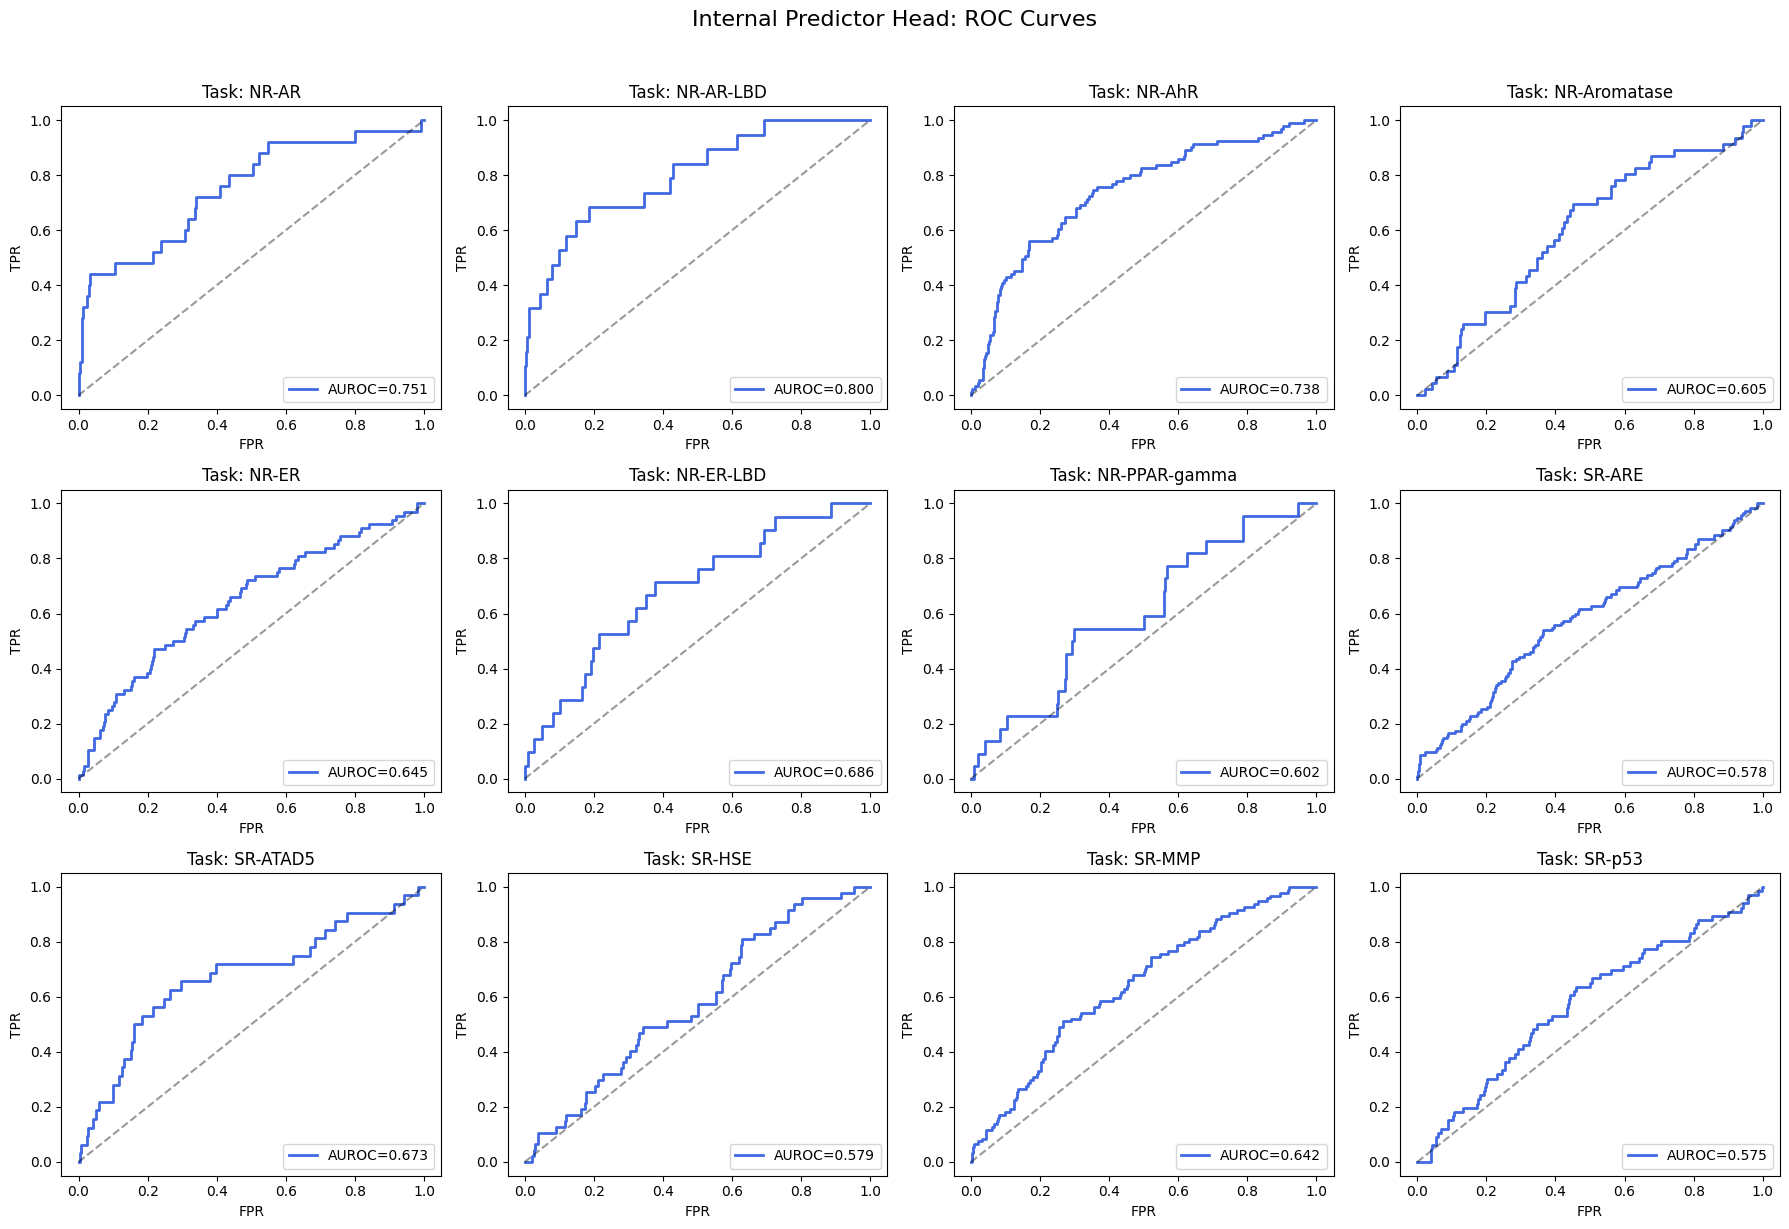

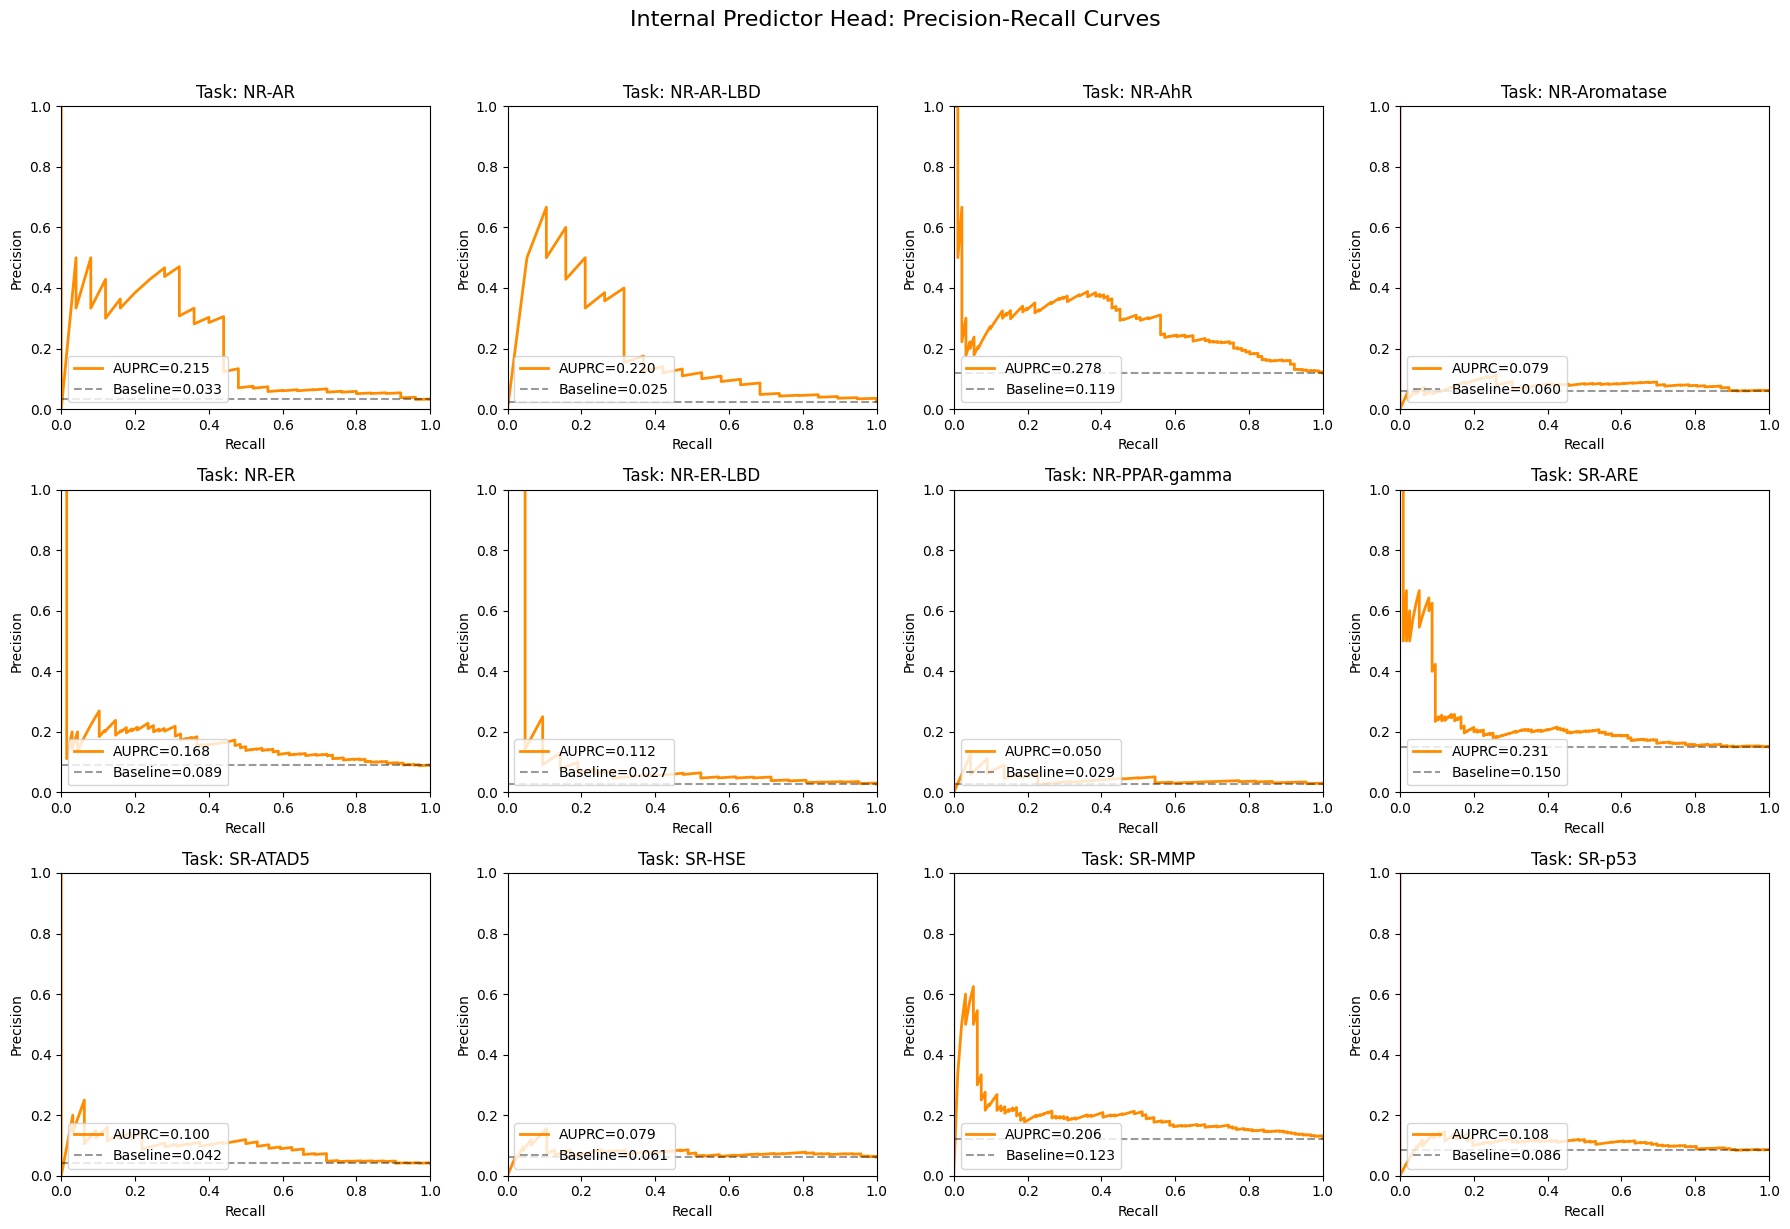

In [16]:
# --- 1. AUROC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: ROC Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, color='royalblue', lw=2, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()

# --- 2. AUPRC PLOTS ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Internal Predictor Head: Precision-Recall Curves", fontsize=16, y=1.02)

for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, color='darkorange', lw=2, label=f"AUPRC={ap:.3f}")
        # Baseline is the proportion of positive samples in the test set
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4, label=f"Baseline={base:.3f}")
        ax.set_title(f"Task: {task}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "Insufficient Variation\nor Task Skipped", 
                ha="center", va="center", color='gray')
        ax.axis("off")

plt.tight_layout()
plt.show()

# Latent Analysis

In [12]:
# Checking vocab size, sequence length, and latent dimension before loading
print(f"VAE Model - VOCAB_SIZE: {VOCAB_SIZE}, SEQ_LEN: {SEQ_LEN}, LATENT_DIM: {LATENT_DIM}")

VAE Model - VOCAB_SIZE: 198, SEQ_LEN: 121, LATENT_DIM: 292


In [13]:
# Initialize with your new class
model = VAEWithPredictor(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN).to(device)
CKPT = Path("artifacts") / "end-to-end_checkpoint" / "e2evae_full_seqconv_ce_phase2_adaptive_best.pt" 

# Load weights
ckpt = torch.load(CKPT, map_location=device, weights_only=True)
state_dict = ckpt["model_state_dict"]
model.load_state_dict(state_dict)
model.eval()

# Test with dummy data (Note: Now passing LongTensor of indices, not one-hot)
dummy_input = torch.zeros((2, SEQ_LEN), dtype=torch.long).to(device)
logits, mean, logvar, pred = model(dummy_input)

print(f"Logits: {logits.shape}") # [2, 121, 198]
print(f"Mean: {mean.shape}")     # [2, 292]
print(f"Preds: {pred.shape}")     # [2, 12]

Logits: torch.Size([2, 121, 198])
Mean: torch.Size([2, 292])
Preds: torch.Size([2, 12])


In [15]:
from umap import UMAP

# 1. Combine all Tox21 splits (Train, Val, Test) for a global view
combined_x = np.concatenate([ft_train_x, ft_val_x, ft_test_x], axis=0)
combined_y = np.concatenate([y_train_ft, y_val_ft, y_test_ft], axis=0)
# We don't strictly need the masks for visualization, but they are available

# 2. Create DataLoader
analysis_ds = VAEDataset(combined_x, combined_y)
analysis_loader = DataLoader(analysis_ds, batch_size=BATCH_SIZE, shuffle=False)

# 3. Extract Latents
model.eval()
all_latents = []

print(f"Extracting latents for {len(combined_x)} molecules...")
with torch.no_grad():
    for batch_x, _, _ in analysis_loader:
        batch_x = batch_x.to(device)
        
        # In your new architecture, 'encode' returns (mu, logvar)
        mu, _ = model.encode(batch_x)
        all_latents.append(mu.cpu().numpy())

all_latents = np.vstack(all_latents)

# 4. Run UMAP
print("Running UMAP dimensionality reduction...")
reducer = UMAP(n_components=2, random_state=SEED)
latents_2d = reducer.fit_transform(all_latents)

# Ensure labels align (in case of any batching truncation, though vstack prevents this)
all_labels_filtered = combined_y[:latents_2d.shape[0], :]
print("Latent extraction and reduction complete.")

d:\AIT\AI-for-Toxicology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting latents for 7772 molecules...
Running UMAP dimensionality reduction...


d:\AIT\AI-for-Toxicology\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Latent extraction and reduction complete.


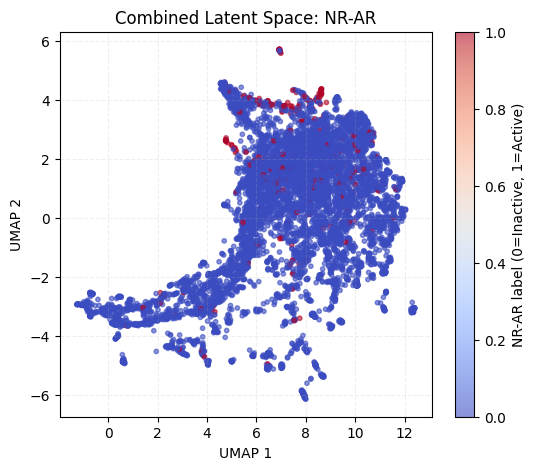

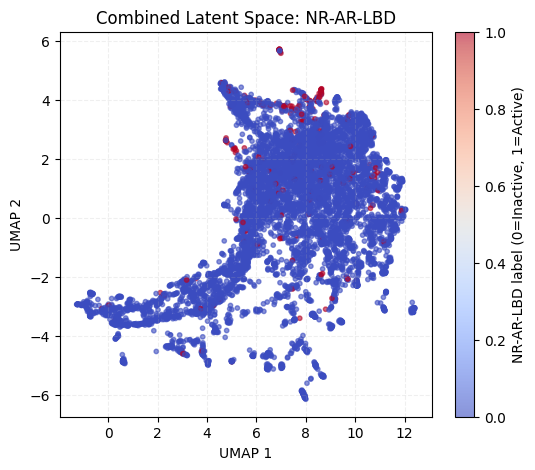

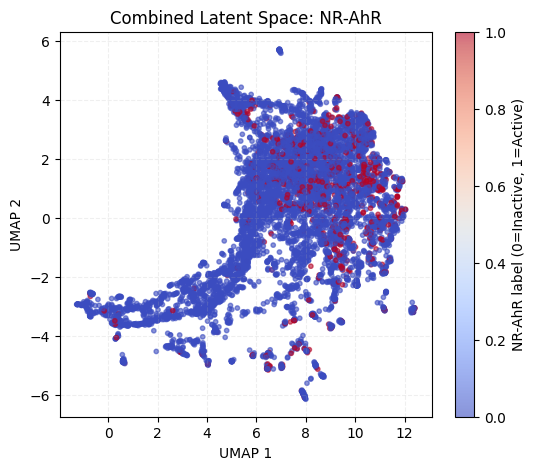

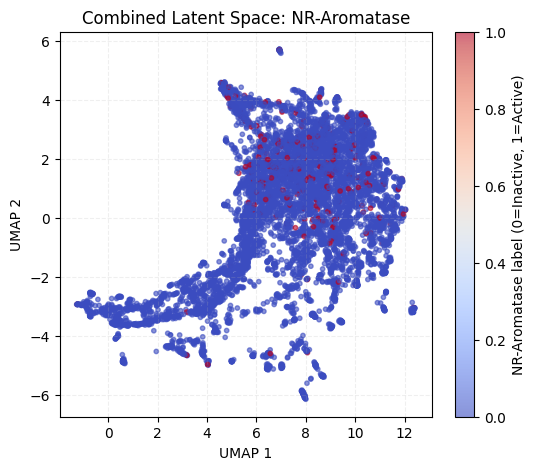

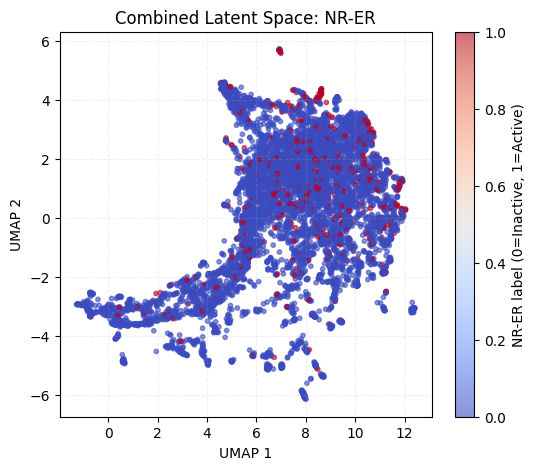

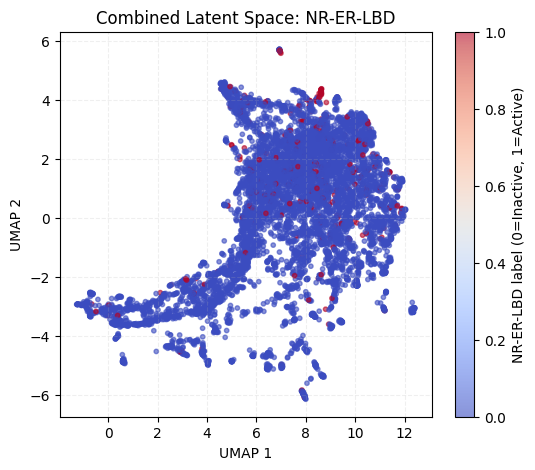

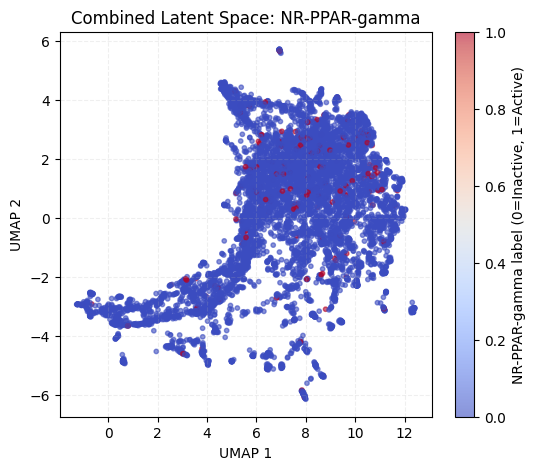

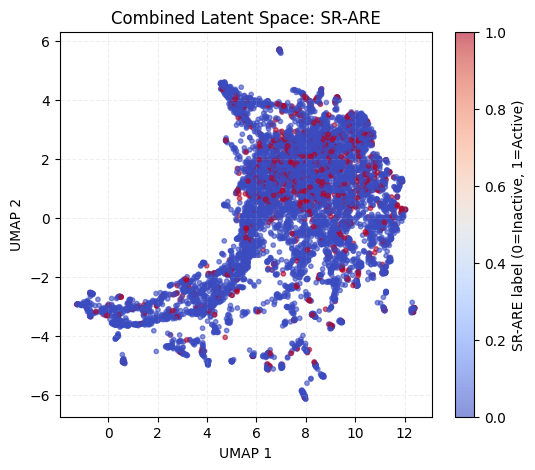

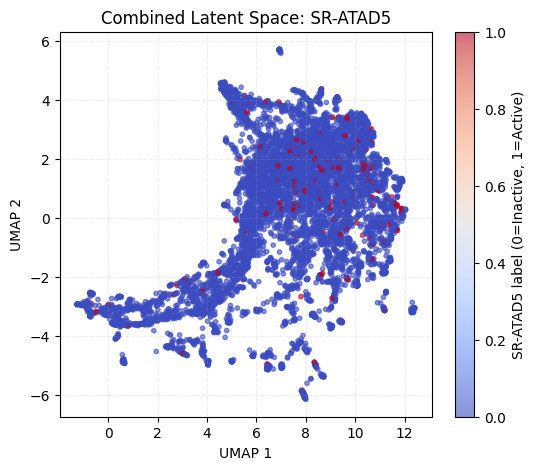

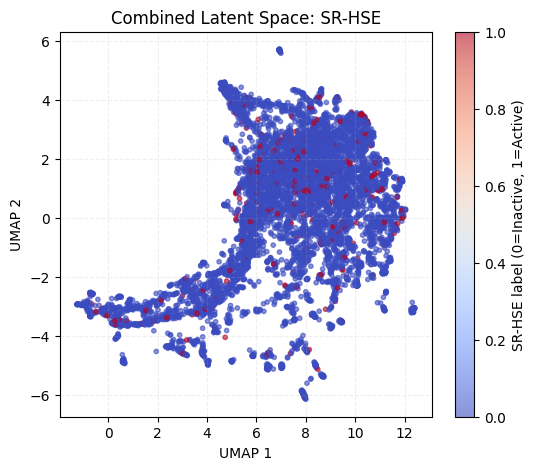

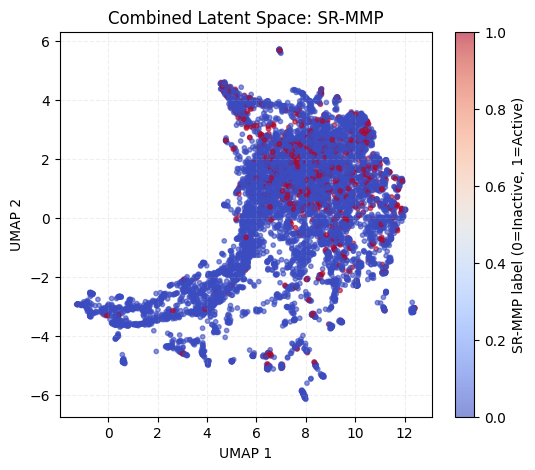

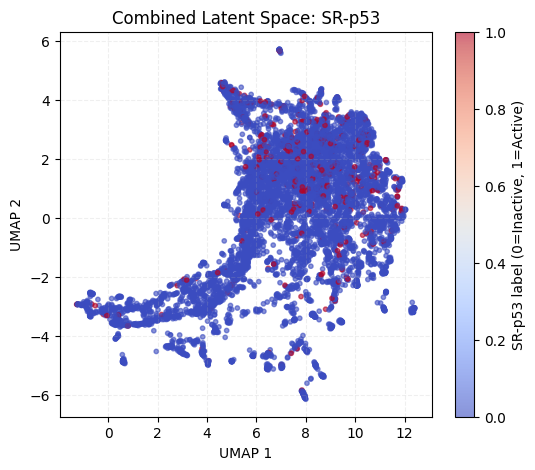

In [19]:
# 4. Plot each individual toxicity task heatmap
for i, task in enumerate(TOX21_TASKS):
    plt.figure(figsize=(6, 5))
    # s=10 makes points smaller for better visibility in dense areas
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], 
                c=all_labels_filtered[:, i], cmap='coolwarm', alpha=0.6, s=10)
    
    plt.colorbar(label=f"{task} label (0=Inactive, 1=Active)")
    plt.title(f"Combined Latent Space: {task}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.show()

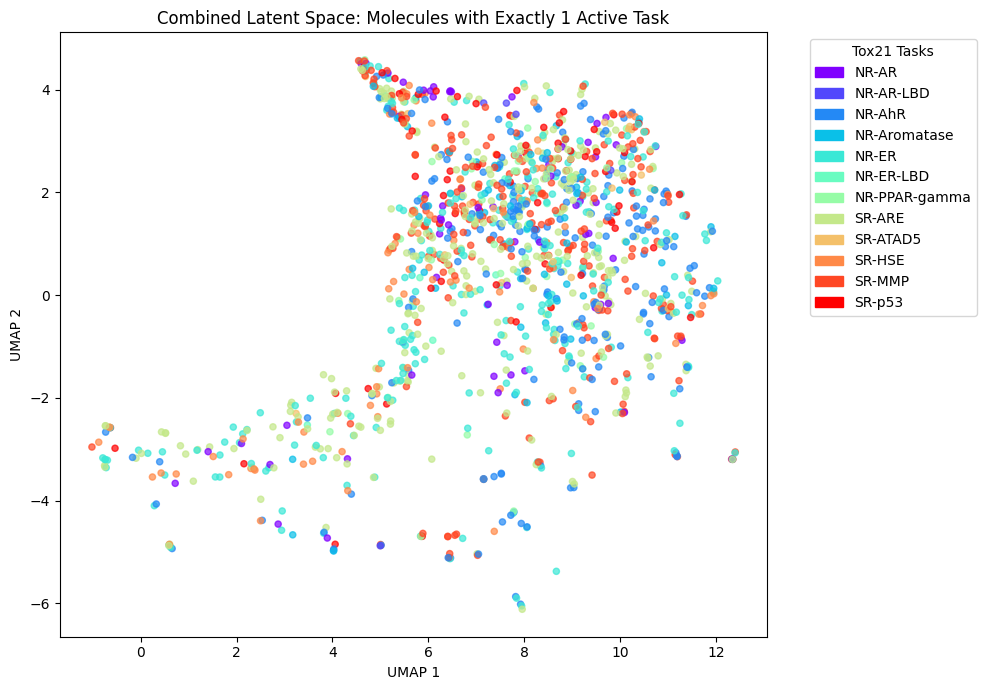

In [20]:
# 5. Plot points with exactly 1 positive label (The Categorical Plot)

# Create a mask for molecules that have exactly one '1' in their label row
single_label_mask = (all_labels_filtered.sum(axis=1) == 1)

latents_single = latents_2d[single_label_mask]
labels_single = all_labels_filtered[single_label_mask]

# Find the index (0-11) of the active task for each molecule
colors_idx = np.argmax(labels_single, axis=1)

# Use a distinct colormap
cmap = plt.get_cmap("rainbow") 

plt.figure(figsize=(10, 7))
scatter = plt.scatter(latents_single[:, 0], latents_single[:, 1],
                      c=colors_idx, cmap=cmap, alpha=0.7, s=20, 
                      vmin=0, vmax=len(TOX21_TASKS)-1)

# Create the Legend manually to match colors to task names
handles = [mpatches.Patch(color=cmap(i / (len(TOX21_TASKS)-1)), label=TOX21_TASKS[i]) 
           for i in range(len(TOX21_TASKS))]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Tox21 Tasks")
plt.title("Combined Latent Space: Molecules with Exactly 1 Active Task")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

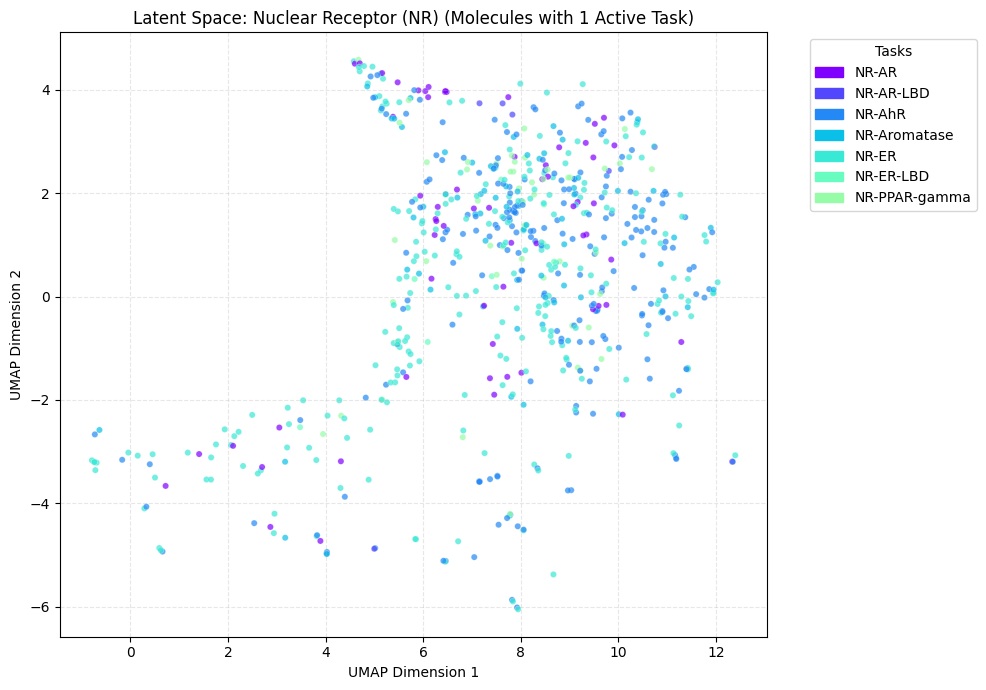

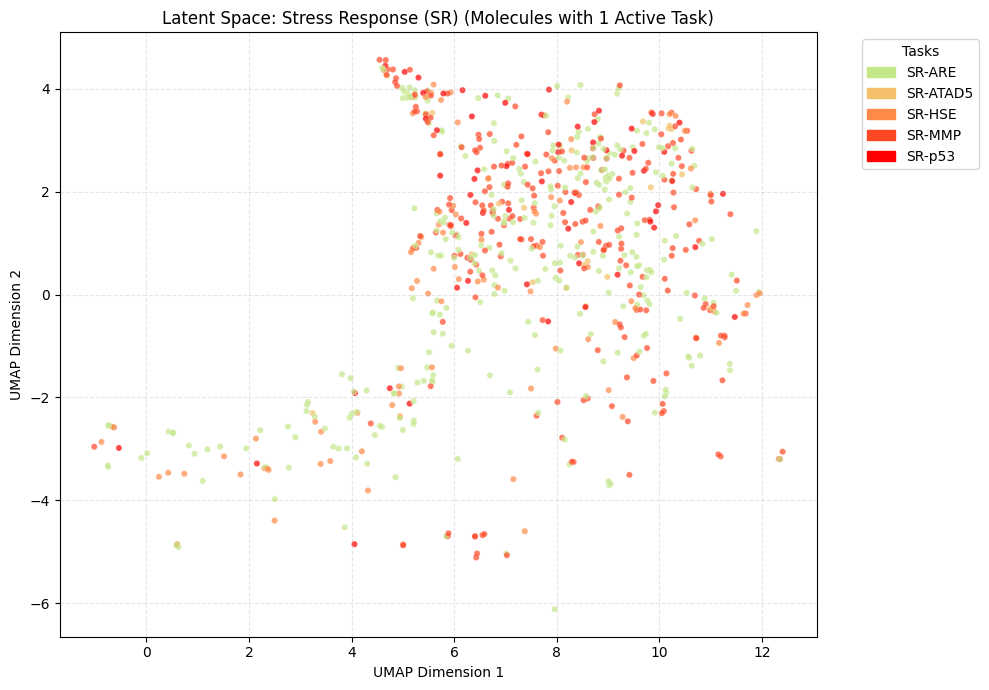

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Use the same colormap you liked from the main plot
cmap = plt.get_cmap("rainbow") 

# Pre-calculate indices based on your TOX21_TASKS list
nr_indices = [i for i, task in enumerate(TOX21_TASKS) if task.startswith('NR')]
sr_indices = [i for i, task in enumerate(TOX21_TASKS) if task.startswith('SR')]

def plot_tox_subset(indices, title_prefix):
    # Filter: Only molecules where exactly ONE of the 12 tasks is positive
    full_single_mask = (all_labels_filtered.sum(axis=1) == 1)
    
    subset_labels = all_labels_filtered[full_single_mask]
    subset_latents = latents_2d[full_single_mask]
    
    # Identify the active task index (0-11)
    active_task_idx = np.argmax(subset_labels, axis=1)
    
    # Keep only points where the active task belongs to our current group (NR or SR)
    group_mask = np.isin(active_task_idx, indices)
    
    final_latents = subset_latents[group_mask]
    final_colors = active_task_idx[group_mask]

    plt.figure(figsize=(10, 7))
    
    # CRITICAL: vmin and vmax MUST be 0 and 11 to keep the colors matched to the main plot
    scatter = plt.scatter(
        final_latents[:, 0], final_latents[:, 1], 
        c=final_colors, 
        cmap=cmap, 
        vmin=0, 
        vmax=len(TOX21_TASKS)-1, 
        alpha=0.7, 
        s=20,
        edgecolors='white',
        linewidths=0.2
    )

    # Create legend handles for only the tasks in this specific subset
    handles = []
    for i in indices:
        # Calculate the exact color from the rainbow map used in the main plot
        # We divide by (len - 1) to match the vmin/vmax normalization
        color = cmap(i / (len(TOX21_TASKS) - 1))
        handles.append(mpatches.Patch(color=color, label=TOX21_TASKS[i]))
    
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Tasks")
    plt.title(f"Latent Space: {title_prefix} (Molecules with 1 Active Task)")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Generate the plots
if len(nr_indices) > 0:
    plot_tox_subset(nr_indices, "Nuclear Receptor (NR)")

if len(sr_indices) > 0:
    plot_tox_subset(sr_indices, "Stress Response (SR)")

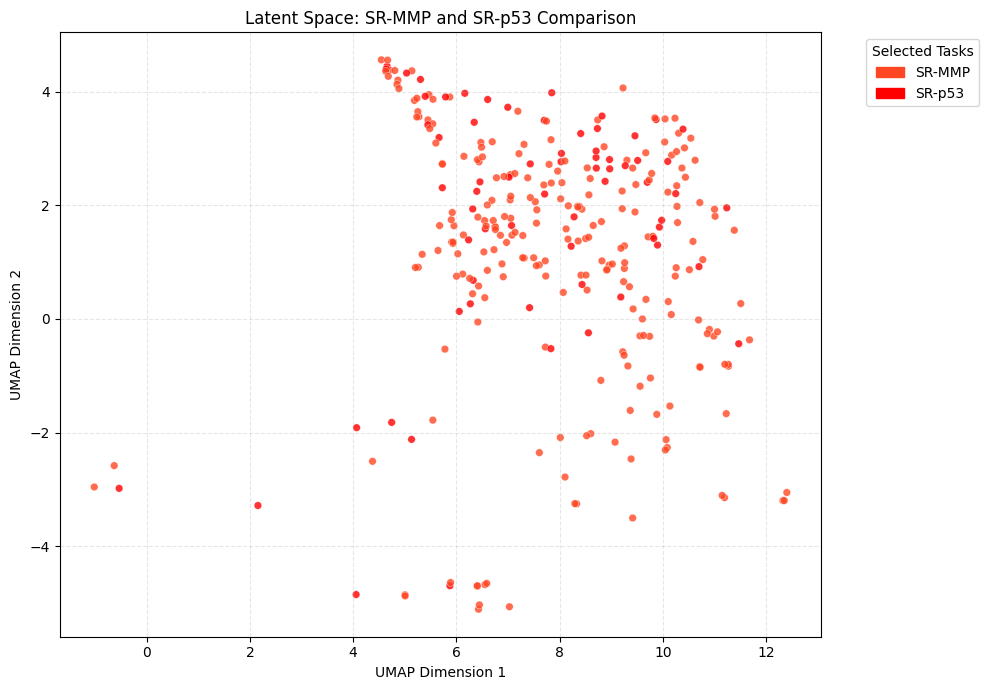

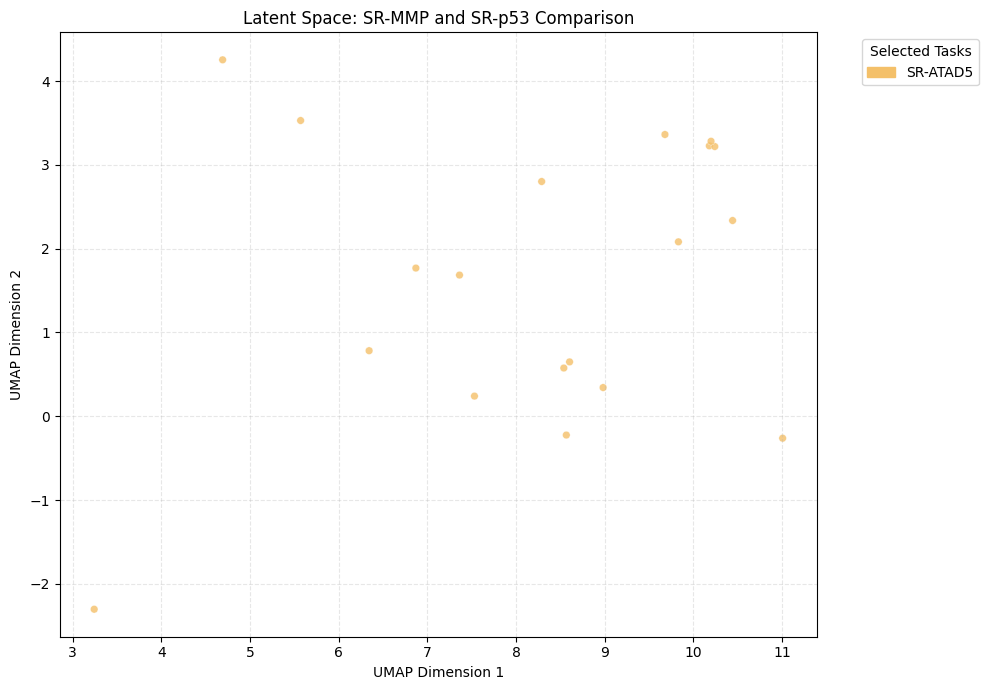

In [26]:
# 1. Identify the specific indices for your target tasks
target_task_names = ["SR-MMP", "SR-p53"]
target_indices = [i for i, task in enumerate(TOX21_TASKS) if task in target_task_names]

# 2. Use the same rainbow colormap
cmap = plt.get_cmap("rainbow")

def plot_specific_tasks(indices, task_names):
    # Mask for molecules with exactly one active task
    full_single_mask = (all_labels_filtered.sum(axis=1) == 1)
    
    subset_labels = all_labels_filtered[full_single_mask]
    subset_latents = latents_2d[full_single_mask]
    
    # Get active task index (0-11)
    active_task_idx = np.argmax(subset_labels, axis=1)
    
    # Filter for ONLY SR-MMP and SR-p53
    group_mask = np.isin(active_task_idx, indices)
    
    final_latents = subset_latents[group_mask]
    final_colors = active_task_idx[group_mask]

    plt.figure(figsize=(10, 7))
    
    # Maintain vmin/vmax consistency with the main 12-task plot
    plt.scatter(
        final_latents[:, 0], final_latents[:, 1], 
        c=final_colors, 
        cmap=cmap, 
        vmin=0, 
        vmax=len(TOX21_TASKS)-1, 
        alpha=0.8, 
        s=30,
        edgecolors='white',
        linewidths=0.3
    )

    # Create legend for just these two
    handles = []
    for i in indices:
        color = cmap(i / (len(TOX21_TASKS) - 1))
        handles.append(mpatches.Patch(color=color, label=TOX21_TASKS[i]))
    
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Selected Tasks")
    plt.title("Latent Space: SR-MMP and SR-p53 Comparison")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the plot
plot_specific_tasks(target_indices, target_task_names)

# 1. Identify the specific indices for your target tasks
target_task_names = ["SR-ATAD5"]
target_indices = [i for i, task in enumerate(TOX21_TASKS) if task in target_task_names]

# 2. Use the same rainbow colormap
cmap = plt.get_cmap("rainbow")

# Run the plot
plot_specific_tasks(target_indices, target_task_names)

# Generative Capability